# Reef Analysis A - Full Dataset (All Observations)


In this analysis, we use the full cleaned dataset, where each row represents an individual observation
of a reef at a specific point in time. This dataset preserves the temporal structure of the data,
including repeated measurements of the same reef across years.

The goal of this analysis is to:
- Identify dominant environmental patterns using PCA
- Explore structure and clustering in the full dataset
- Examine how reef conditions vary over time

Note:
Because some reefs are sampled more frequently than others, this dataset may overrepresent
heavily monitored reefs. Results from this analysis are therefore compared with an aggregated
reef-level dataset in Analysis B to assess the impact of sampling imbalance.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Load Data
df = pd.read_csv("cleaned_data/dataset_A.csv")

# Recompute feature columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ["Site_ID", "Sample_ID", "year", "Percent_Bleaching"]

feature_cols = [c for c in numeric_cols if c not in exclude_cols]

X = df[feature_cols].copy()

X.head()

,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,TSA,TSA_Maximum,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMean,TSA_DHW,TSA_DHWMax
0,23.163,-82.5260,8519.23,0.0287,49.90,10.00,NaN,301.61,302.05,300.67,296.72,304.69,8.0,-0.46,1.0,-3.56,2.24,0.0,3.13,3.0,0.00,1.63,7.88,-0.80,1.83,0.00,1.09,0.0,0.00,7.25
1,-17.575,-149.7833,1431.62,0.0262,51.20,14.00,NaN,262.15,303.30,300.73,297.58,305.01,2.0,1.29,1.0,-2.73,3.10,0.5,2.77,2.0,0.26,1.48,11.41,1.29,3.00,0.25,0.93,0.0,0.26,4.65
2,18.369,-64.5640,182.33,0.0429,61.52,7.00,NaN,298.79,299.18,300.32,297.12,304.14,8.0,0.04,1.0,-2.92,2.83,16.0,4.52,3.0,0.00,2.45,16.24,-2.64,2.31,7.00,1.31,0.0,0.00,11.66
3,17.760,-64.5680,313.13,0.0424,65.39,9.02,NaN,300.16,299.61,300.38,297.25,304.07,3.0,-0.07,1.0,-2.77,2.47,22.0,4.75,3.0,0.00,2.37,16.73,-2.27,2.19,3.00,0.94,0.0,0.00,5.64
4,17.769,-64.5830,792.00,0.0424,65.39,12.50,NaN,300.15,299.70,300.38,296.63,303.76,3.0,0.00,1.0,-2.84,2.30,16.0,4.16,3.0,0.00,2.24,13.86,-2.19,1.87,3.00,1.33,0.0,0.00,6.89


In [55]:
print(df["Percent_Cover"].isna().mean())

0.3011290829525398


In [56]:
# Impute and scale data.

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

Now we can procede with PCA:

In [57]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

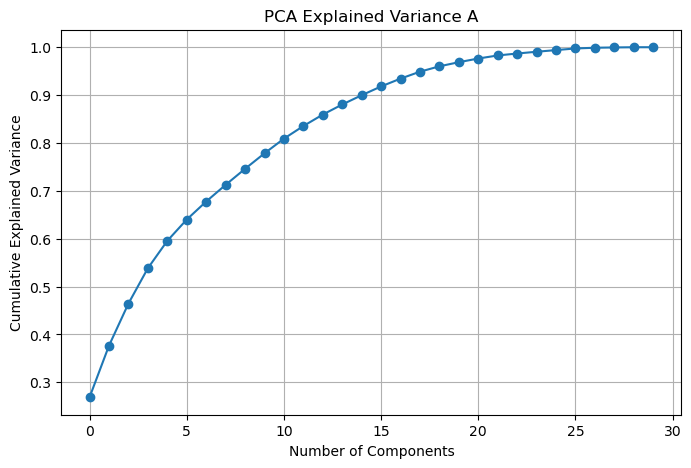

In [83]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance A")
plt.grid(True)
plt.show()

Next, we can plot the the first two principle components.

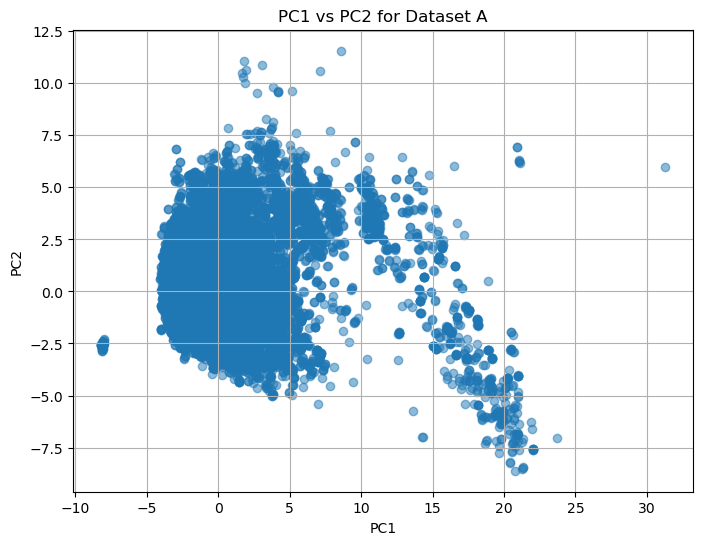

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 for Dataset A")
plt.grid(True)
plt.show()

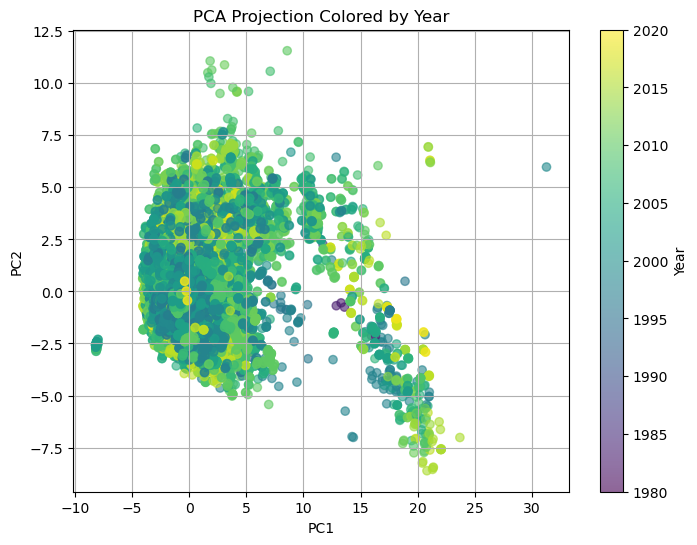

In [60]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["year"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Year")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Colored by Year")
plt.grid(True)
plt.show()

In [61]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))],
    index=feature_cols
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
Latitude_Degrees,0.032752,-0.022815,-0.140569,0.465176,0.235734,-0.337845,0.052422,0.029105,0.076954,-0.038919,0.004403,0.037102,-0.189795,0.140676,0.132283,-0.133663,-0.005563,-0.235327,-0.371615,0.462959,-0.195216,0.083314,-0.146529,-0.116134,-0.014843,-0.004204,-0.020276,0.009734,-0.018682,0.002105
Longitude_Degrees,0.113660,0.070240,0.219198,-0.252062,-0.405437,-0.059269,0.060087,0.182655,0.083139,0.083382,-0.067577,-0.023149,0.191358,-0.194724,-0.441942,0.132763,-0.085432,0.059566,-0.228246,0.482682,-0.212745,0.016645,-0.048878,-0.066006,0.089769,0.020803,0.012438,0.045976,0.016758,0.003099
Distance_to_Shore,-0.003329,0.041734,-0.037878,-0.076232,-0.085288,0.393162,0.384011,0.254522,0.506803,0.024944,0.139667,0.504866,-0.073194,0.070338,0.251328,-0.050176,-0.004827,-0.002457,0.002239,0.037067,-0.056625,0.042770,-0.021739,0.003325,-0.035754,0.010415,-0.026611,0.003759,-0.003341,0.000323
Turbidity,0.127901,0.080862,0.123981,0.243798,-0.170742,0.162880,0.128314,-0.105528,-0.316033,0.086287,-0.095317,0.059291,0.608738,0.366128,0.313080,0.035933,-0.156254,0.145089,-0.142159,0.014755,0.004918,0.098380,-0.001310,-0.113801,0.001062,-0.076470,0.026210,-0.004822,0.007637,-0.000143
Cyclone_Frequency,-0.010162,0.010492,-0.153955,0.270054,0.157848,-0.203165,0.178933,0.030679,0.393868,-0.316427,-0.442059,-0.039268,0.358402,-0.319336,-0.076367,0.100778,-0.177023,0.150513,0.183861,-0.110658,0.025410,0.022437,0.055990,-0.001490,0.028005,-0.009996,0.003029,-0.010135,-0.007027,-0.000717


In [62]:
loadings["PC1"].sort_values(key=abs, ascending=False).head(10)

SSTA_DHW_Standard_Deviation         0.329251
SSTA_Standard_Deviation             0.309457
SSTA_FrequencyMean                  0.309330
SSTA_DHWMax                         0.285833
TSA_DHWMax                          0.279300
TSA_FrequencyMean                   0.263948
SSTA_Maximum                        0.232460
TSA_Maximum                         0.226106
TSA_Frequency                       0.221615
TSA_Frequency_Standard_Deviation    0.215177
Name: PC1, dtype: float64

In [63]:
loadings["PC2"].sort_values(key=abs, ascending=False).head(10)

Temperature_Kelvin    -0.465784
TSA                   -0.402722
Temperature_Mean      -0.400669
Temperature_Minimum   -0.358855
Windspeed              0.245659
SSTA                  -0.238327
TSA_DHW               -0.175037
Temperature_Maximum   -0.174046
TSA_Frequency         -0.152386
SSTA_DHW              -0.148537
Name: PC2, dtype: float64

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


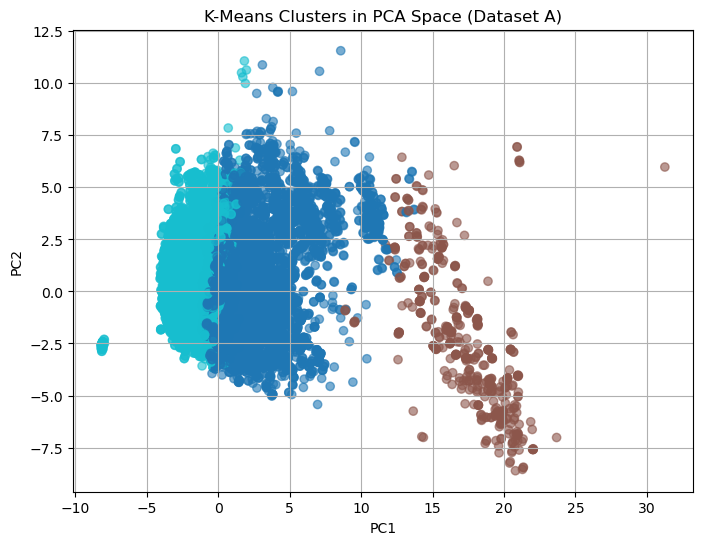

In [90]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :5])  # use top PCs

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space (Dataset A)")
plt.grid(True)
plt.show()

In [65]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :15])

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [66]:
df["cluster"] = clusters

df_bleach = df.dropna(subset=["Percent_Bleaching"]).copy()

df_bleach.groupby("cluster")["Percent_Bleaching"].mean()

cluster
0    10.194584
1     8.675724
2    14.838907
Name: Percent_Bleaching, dtype: float64

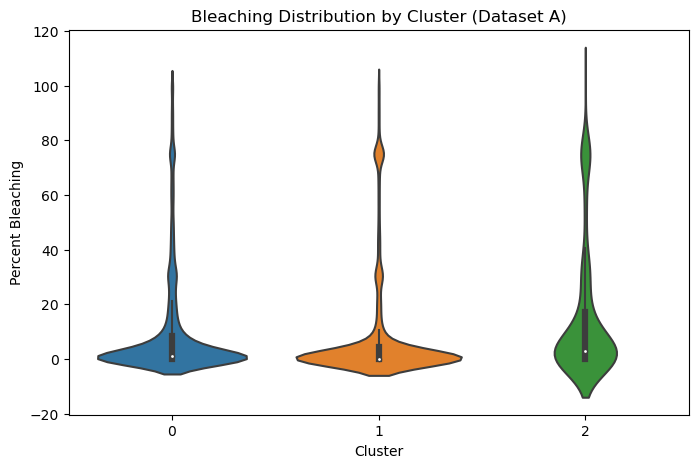

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.violinplot(x="cluster", y="Percent_Bleaching", data=df_bleach)

plt.title("Bleaching Distribution by Cluster (Dataset A)")
plt.xlabel("Cluster")
plt.ylabel("Percent Bleaching")

plt.show()

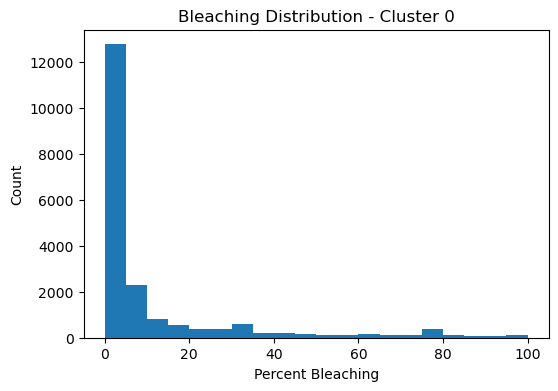

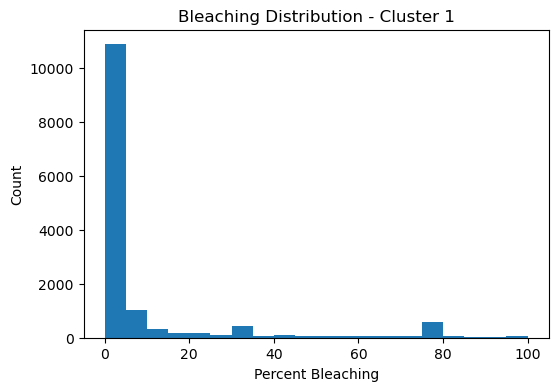

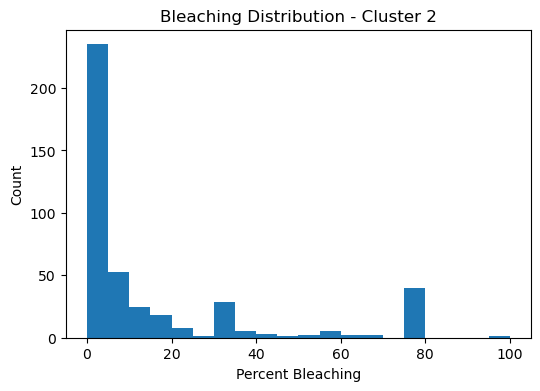

In [73]:
for c in sorted(df_bleach["cluster"].unique()):
    subset = df_bleach[df_bleach["cluster"] == c]
    
    plt.figure(figsize=(6,4))
    plt.hist(subset["Percent_Bleaching"], bins=20)
    
    plt.title(f"Bleaching Distribution - Cluster {c}")
    plt.xlabel("Percent Bleaching")
    plt.ylabel("Count")
    
    plt.show()

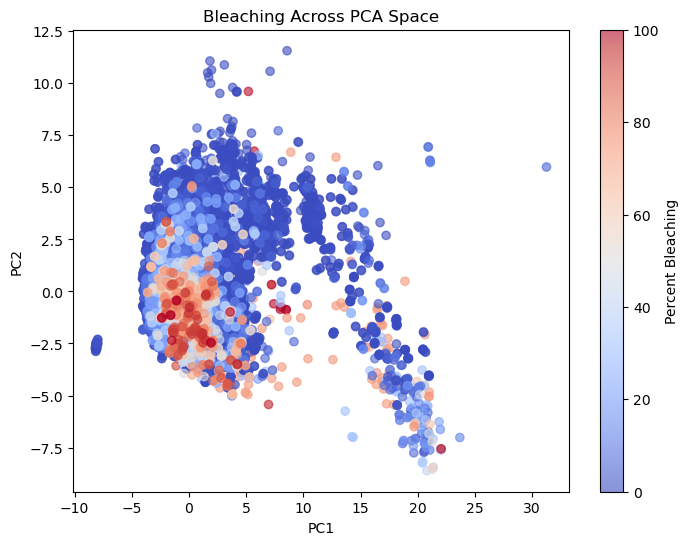

In [75]:
bleach_idx = df_bleach.index

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[bleach_idx, 0],
    X_pca[bleach_idx, 1],
    c=df_bleach["Percent_Bleaching"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(scatter, label="Percent Bleaching")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Bleaching Across PCA Space")
plt.show()

In [78]:
for i in range(20):
    corr = np.corrcoef(
        X_pca[bleach_idx, i],
        df_bleach["Percent_Bleaching"]
    )[0,1]
    
    print(f"PC{i+1} correlation with bleaching:", corr)

PC1 correlation with bleaching: 0.046250879349425164
PC2 correlation with bleaching: -0.13104549117496367
PC3 correlation with bleaching: -0.2802319154383085
PC4 correlation with bleaching: 0.05181381453747195
PC5 correlation with bleaching: 0.05774354530821469
PC6 correlation with bleaching: 0.11498561576654645
PC7 correlation with bleaching: 0.02285652204328926
PC8 correlation with bleaching: 0.13691986162593905
PC9 correlation with bleaching: -0.07498200788209174
PC10 correlation with bleaching: 0.090705139995589
PC11 correlation with bleaching: -0.007836085824649256
PC12 correlation with bleaching: -0.019310946589847146
PC13 correlation with bleaching: -0.04308733840830876
PC14 correlation with bleaching: 0.028715476289440194
PC15 correlation with bleaching: -0.03675826542308099
PC16 correlation with bleaching: -0.08223749493416489
PC17 correlation with bleaching: 0.06983230870652539
PC18 correlation with bleaching: 0.09574774913000424
PC19 correlation with bleaching: 0.05447448225

In [79]:
from sklearn.linear_model import LinearRegression

X_reg = X_pca[bleach_idx, :15]
y_reg = df_bleach["Percent_Bleaching"]

model = LinearRegression()
model.fit(X_reg, y_reg)

print("R^2:", model.score(X_reg, y_reg))

R^2: 0.15322129684310837


In [80]:
loadings["PC3"].sort_values(key=abs, ascending=False).head(10)

Temperature_Maximum                 0.386885
SSTA_DHW                           -0.329714
TSA_DHW                            -0.300341
Temperature_Mean                    0.284583
SSTA_Frequency                     -0.243695
TSA_Frequency                      -0.231549
SSTA                               -0.230206
TSA_Maximum                         0.228796
Longitude_Degrees                   0.219198
TSA_Frequency_Standard_Deviation    0.217449
Name: PC3, dtype: float64

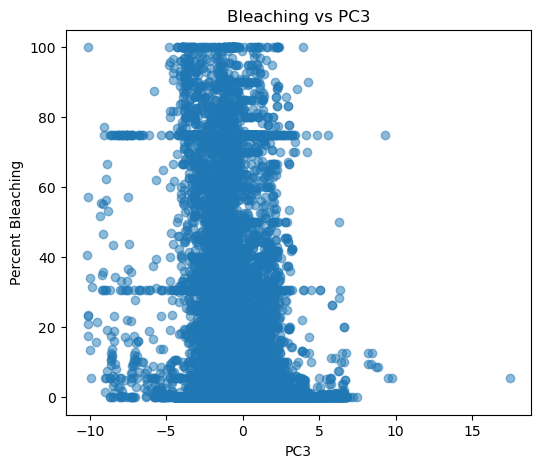

In [81]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[bleach_idx, 2],  # PC3
    df_bleach["Percent_Bleaching"],
    alpha=0.5
)

plt.xlabel("PC3")
plt.ylabel("Percent Bleaching")
plt.title("Bleaching vs PC3")

plt.show()

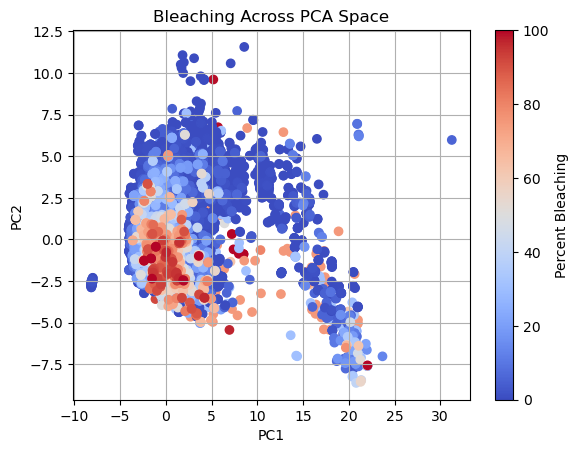

In [86]:
plt.scatter(X_pca[bleach_idx,0], X_pca[bleach_idx,1], 
            c=df_bleach["Percent_Bleaching"], cmap="coolwarm")
plt.colorbar(label="Percent Bleaching")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Bleaching Across PCA Space")
plt.grid(True)
plt.show()